# TCGA-PRAD Exploratory Data Analysis
### Prostate Adenocarcinoma RNA-Seq Gene Expression — Data Exploration

This notebook documents the exploratory analysis performed before building the classification pipeline. It covers:

1. **Data loading and structure** — what the raw data looks like
2. **Sample classification** — tumor vs normal from TCGA barcodes
3. **Expression value distributions** — understanding the log2 scale
4. **Variance analysis** — why we filter low-variance genes
5. **Expression filtering** — why we set the mean threshold at 1.0
6. **Preprocessing impact** — before vs after filtering
7. **PCA exploration** — visualizing sample separation
8. **Top gene investigation** — what the most discriminating genes look like

> **Note:** Run this from the project root with the virtual environment activated.
> The data file should already be in `data/TCGA-PRAD_HiSeqV2.gz`.

## 1. Data Loading and Structure

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Set plotting style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load raw data
df_raw = pd.read_csv('../data/TCGA-PRAD_HiSeqV2.gz', sep='\t', index_col=0)
print(f"Raw data shape: {df_raw.shape}")
print(f"  → {df_raw.shape[0]} genes × {df_raw.shape[1]} samples")
print(f"\nIndex name: {df_raw.index.name}")
print(f"First 5 genes: {df_raw.index[:5].tolist()}")
print(f"First 3 samples: {df_raw.columns[:3].tolist()}")
print(f"\nData types: {df_raw.dtypes.unique()}")
print(f"Missing values: {df_raw.isna().sum().sum()}")
print(f"\nValue range: {df_raw.values.min():.3f} to {df_raw.values.max():.3f}")

Raw data shape: (20530, 550)
  → 20530 genes × 550 samples

Index name: sample
First 5 genes: ['ARHGEF10L', 'HIF3A', 'RNF17', 'RNF10', 'RNF11']
First 3 samples: ['TCGA-XJ-A83F-01', 'TCGA-G9-6348-01', 'TCGA-CH-5766-01']

Data types: [dtype('float64')]
Missing values: 0

Value range: 0.000 to 22.721


In [3]:
# Transpose so rows = samples, columns = genes (ML convention)
df = df_raw.T
print(f"Transposed shape: {df.shape}")
print(f"  → {df.shape[0]} samples × {df.shape[1]} genes")
print(f"\nFirst 3 rows × 5 columns:")
df.iloc[:3, :5]

Transposed shape: (550, 20530)
  → 550 samples × 20530 genes

First 3 rows × 5 columns:


sample,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11
TCGA-XJ-A83F-01,9.3554,5.1517,0.0000,12.4656,11.1274
TCGA-G9-6348-01,8.8729,5.9049,0.4008,12.3538,11.5348
TCGA-CH-5766-01,8.5581,4.9716,0.7574,12.2950,11.9867


## 2. Sample Classification from TCGA Barcodes

In [4]:
# TCGA barcodes encode sample type in positions after the 3rd hyphen
# 01-09 = tumor, 10-19 = normal adjacent tissue

def classify_barcode(barcode):
    code = int(barcode.split('-')[3][:2])
    if 1 <= code <= 9:
        return 'tumor'
    elif 10 <= code <= 19:
        return 'normal'
    return None

df['class'] = df.index.map(classify_barcode)
counts = df['class'].value_counts()

print("Sample classification:")
print(f"  Tumor:  {counts.get('tumor', 0)}")
print(f"  Normal: {counts.get('normal', 0)}")
print(f"  Total:  {len(df)}")
print(f"\nImbalance ratio: {counts['tumor'] / counts['normal']:.1f}:1")
print(f"Normal samples are only {counts['normal']/len(df)*100:.1f}% of the dataset")

Sample classification:
  Tumor:  498
  Normal: 52
  Total:  550

Imbalance ratio: 9.6:1
Normal samples are only 9.5% of the dataset


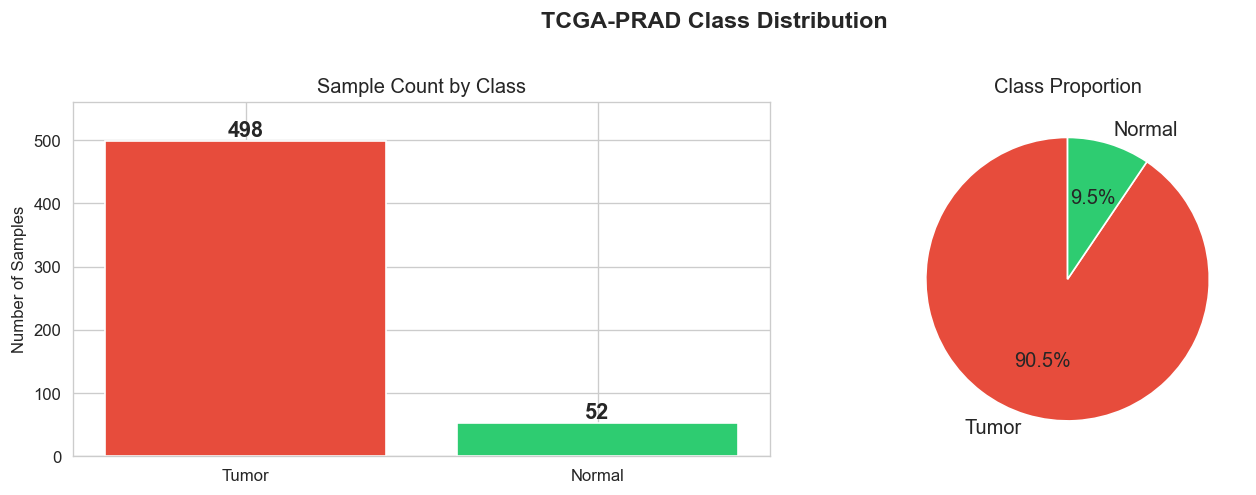


→ Significant class imbalance. This is important for classifier evaluation —
  a naive classifier predicting 'tumor' for everything would get 90.5% accuracy.


In [5]:
# Visualize the class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(['Tumor', 'Normal'], [counts['tumor'], counts['normal']], color=colors, edgecolor='white')
for i, v in enumerate([counts['tumor'], counts['normal']]):
    axes[0].text(i, v + 8, str(v), ha='center', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('Sample Count by Class')
axes[0].set_ylim(0, 560)

# Pie chart
axes[1].pie([counts['tumor'], counts['normal']], labels=['Tumor', 'Normal'],
           colors=colors, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Class Proportion')

plt.suptitle('TCGA-PRAD Class Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n→ Significant class imbalance. This is important for classifier evaluation —")
print("  a naive classifier predicting 'tumor' for everything would get 90.5% accuracy.")

## 3. Expression Value Distributions

The data is in **log2(RSEM normalized count + 1)** scale. Let's understand what this means:
- A value of 0 means the gene is completely silent (count = 0)
- A value of 1 means count = 1 (very low expression)  
- A value of 10 means count = 1,023 (moderate expression)
- A value of 15+ means very high expression

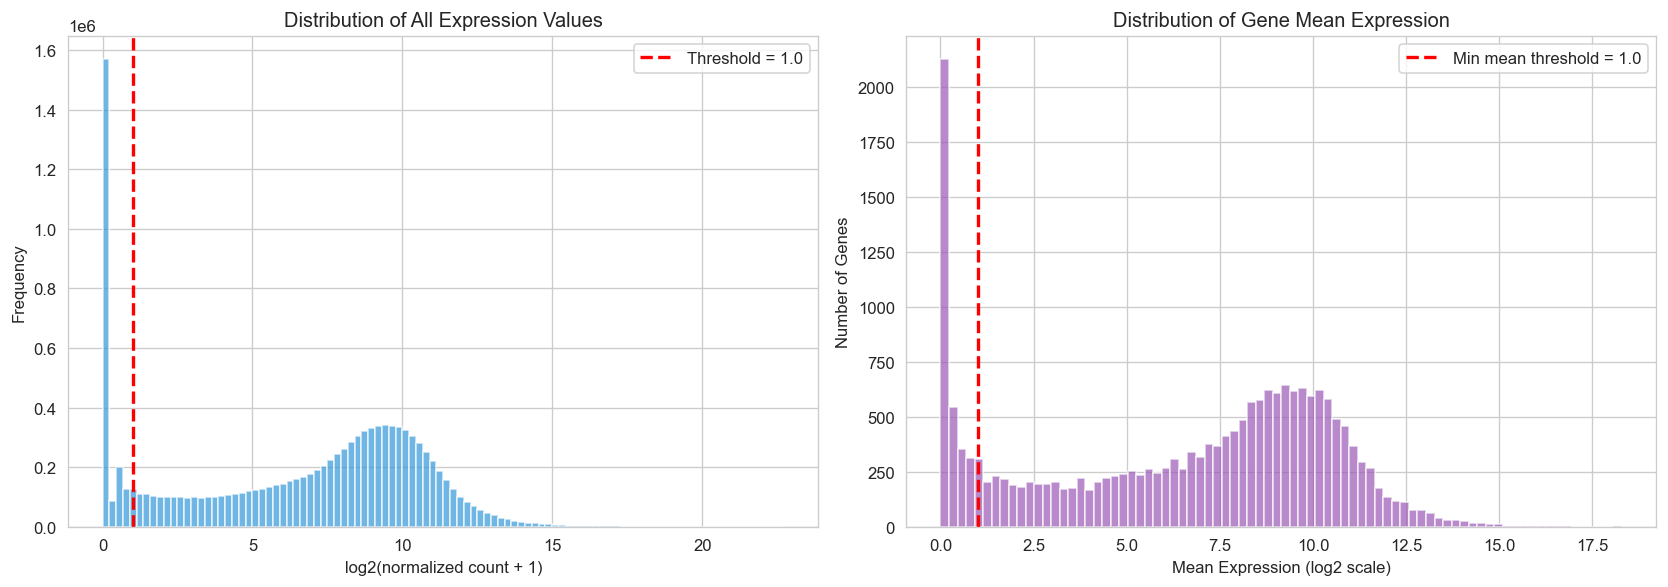

Total genes: 20530
Genes with mean < 1.0: 3461 (16.9%)
Genes with mean = 0 (completely silent): 298

→ 3461 genes are essentially inactive in prostate tissue.
  Removing them reduces noise without losing discriminating signal.


In [6]:
# Overall distribution of expression values
expr = df.drop(columns=['class'])
all_values = expr.values.flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all expression values
axes[0].hist(all_values, bins=100, color='#3498db', alpha=0.7, edgecolor='white')
axes[0].axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Threshold = 1.0')
axes[0].set_xlabel('log2(normalized count + 1)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of All Expression Values')
axes[0].legend()

# Distribution of gene means
gene_means = expr.mean()
axes[1].hist(gene_means, bins=80, color='#9b59b6', alpha=0.7, edgecolor='white')
axes[1].axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Min mean threshold = 1.0')
axes[1].set_xlabel('Mean Expression (log2 scale)')
axes[1].set_ylabel('Number of Genes')
axes[1].set_title('Distribution of Gene Mean Expression')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Total genes: {len(gene_means)}")
print(f"Genes with mean < 1.0: {(gene_means < 1.0).sum()} ({(gene_means < 1.0).mean()*100:.1f}%)")
print(f"Genes with mean = 0 (completely silent): {(gene_means == 0).sum()}")
print(f"\n→ {(gene_means < 1.0).sum()} genes are essentially inactive in prostate tissue.")
print("  Removing them reduces noise without losing discriminating signal.")

## 4. Variance Analysis — Why Filter Low-Variance Genes?

A gene that has the *same* expression level in every sample — whether tumor or normal — 
cannot help distinguish between the two classes. We measure variance across all samples and 
remove genes in the bottom 25th percentile.

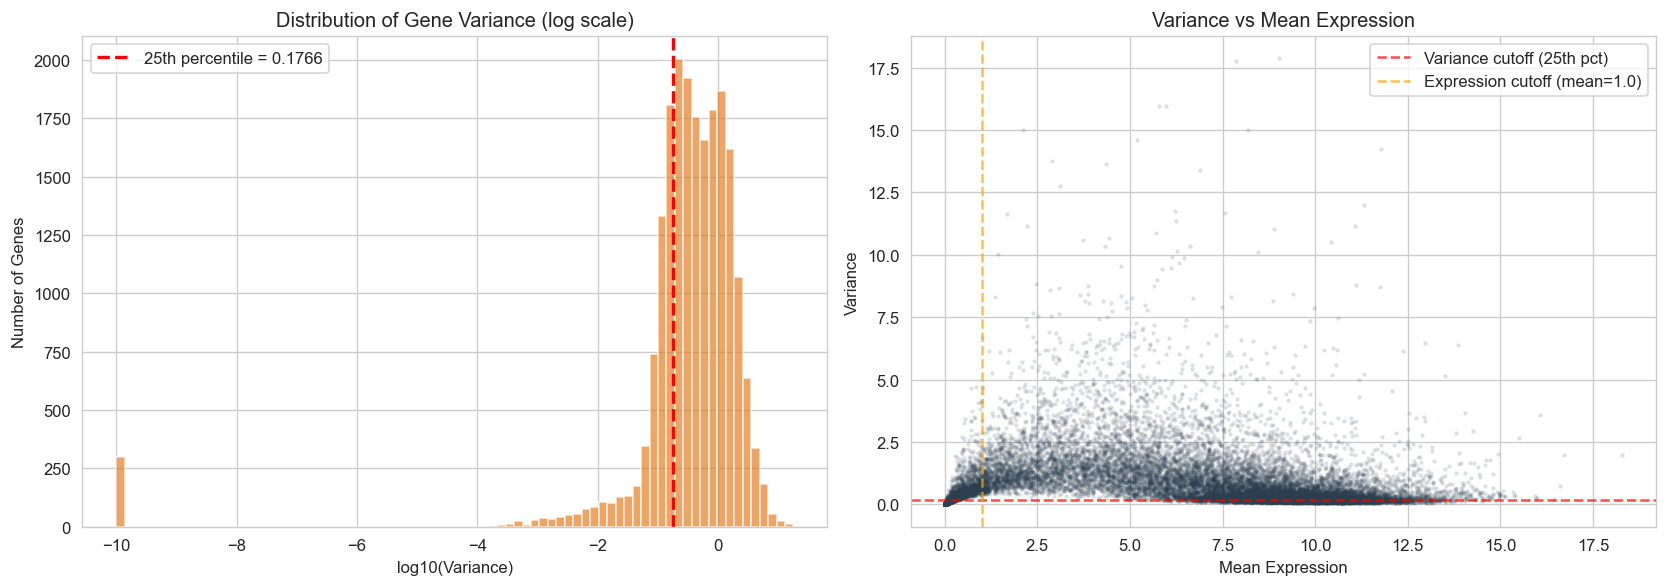

Variance 25th percentile cutoff: 0.1766
Genes below cutoff: 5133

→ Bottom-right quadrant (high mean, low variance) = housekeeping genes.
  These are always on but don't differ between tumor and normal.
  Bottom-left quadrant = genes that are both silent and invariant. Pure noise.


In [7]:
gene_vars = expr.var()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of variance (log scale for visibility)
axes[0].hist(np.log10(gene_vars + 1e-10), bins=80, color='#e67e22', alpha=0.7, edgecolor='white')
cutoff_25 = np.percentile(gene_vars, 25)
axes[0].axvline(x=np.log10(cutoff_25), color='red', linestyle='--', linewidth=2,
               label=f'25th percentile = {cutoff_25:.4f}')
axes[0].set_xlabel('log10(Variance)')
axes[0].set_ylabel('Number of Genes')
axes[0].set_title('Distribution of Gene Variance (log scale)')
axes[0].legend()

# Variance vs Mean expression (MA-style plot)
axes[1].scatter(gene_means, gene_vars, alpha=0.1, s=3, color='#2c3e50')
axes[1].axhline(y=cutoff_25, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
               label=f'Variance cutoff (25th pct)')
axes[1].axvline(x=1.0, color='orange', linestyle='--', linewidth=1.5, alpha=0.7,
               label='Expression cutoff (mean=1.0)')
axes[1].set_xlabel('Mean Expression')
axes[1].set_ylabel('Variance')
axes[1].set_title('Variance vs Mean Expression')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Variance 25th percentile cutoff: {cutoff_25:.4f}")
print(f"Genes below cutoff: {(gene_vars < cutoff_25).sum()}")
print(f"\n→ Bottom-right quadrant (high mean, low variance) = housekeeping genes.")
print("  These are always on but don't differ between tumor and normal.")
print("  Bottom-left quadrant = genes that are both silent and invariant. Pure noise.")

## 5. Preprocessing Impact — Before vs After Filtering

In [8]:
# Apply both filters
mask_expression = gene_means >= 1.0
mask_variance = gene_vars >= cutoff_25
mask_both = mask_expression & mask_variance

print("Filtering summary:")
print(f"  Starting genes:              {len(gene_means):>6}")
print(f"  After expression filter:     {mask_expression.sum():>6}  (removed {(~mask_expression).sum()})")
print(f"  After variance filter:       {mask_variance.sum():>6}  (removed {(~mask_variance).sum()})")
print(f"  After BOTH filters:          {mask_both.sum():>6}  (removed {(~mask_both).sum()})")
print(f"\n  Compression: {len(gene_means)} → {mask_both.sum()} genes ({mask_both.sum()/len(gene_means)*100:.1f}% retained)")

Filtering summary:
  Starting genes:               20530
  After expression filter:      17069  (removed 3461)
  After variance filter:        15397  (removed 5133)
  After BOTH filters:           13874  (removed 6656)

  Compression: 20530 → 13874 genes (67.6% retained)


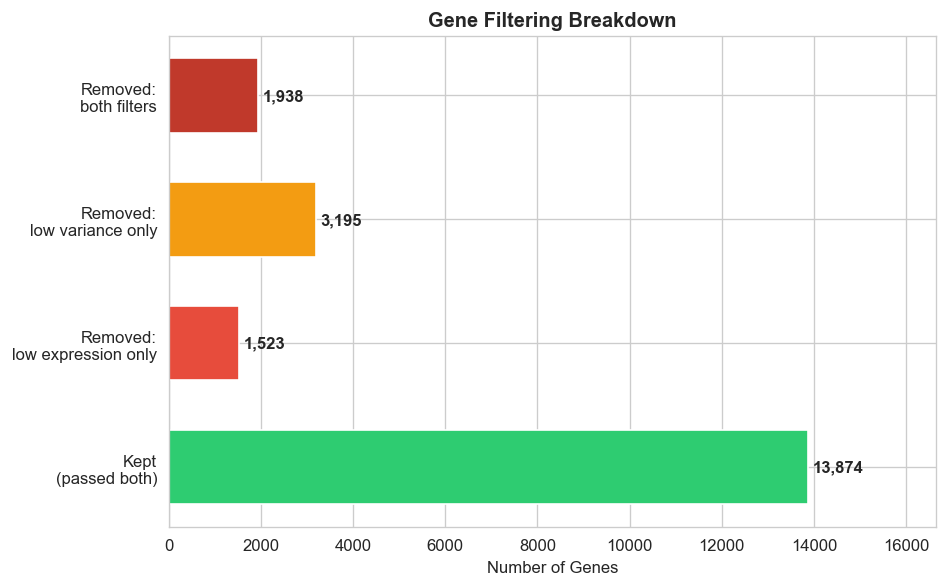

In [9]:
# Venn-style overlap
only_expr = (~mask_expression & mask_variance).sum()
only_var = (mask_expression & ~mask_variance).sum()
both_removed = (~mask_expression & ~mask_variance).sum()
kept = mask_both.sum()

fig, ax = plt.subplots(figsize=(8, 5))
categories = ['Kept\n(passed both)', 'Removed:\nlow expression only',
              'Removed:\nlow variance only', 'Removed:\nboth filters']
values = [kept, only_expr, only_var, both_removed]
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#c0392b']

bars = ax.barh(categories, values, color=colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
           f'{val:,}', va='center', fontweight='bold')

ax.set_xlabel('Number of Genes')
ax.set_title('Gene Filtering Breakdown', fontweight='bold')
ax.set_xlim(0, max(values) * 1.2)
plt.tight_layout()
plt.show()

## 6. PCA Exploration — Do Tumor and Normal Separate?

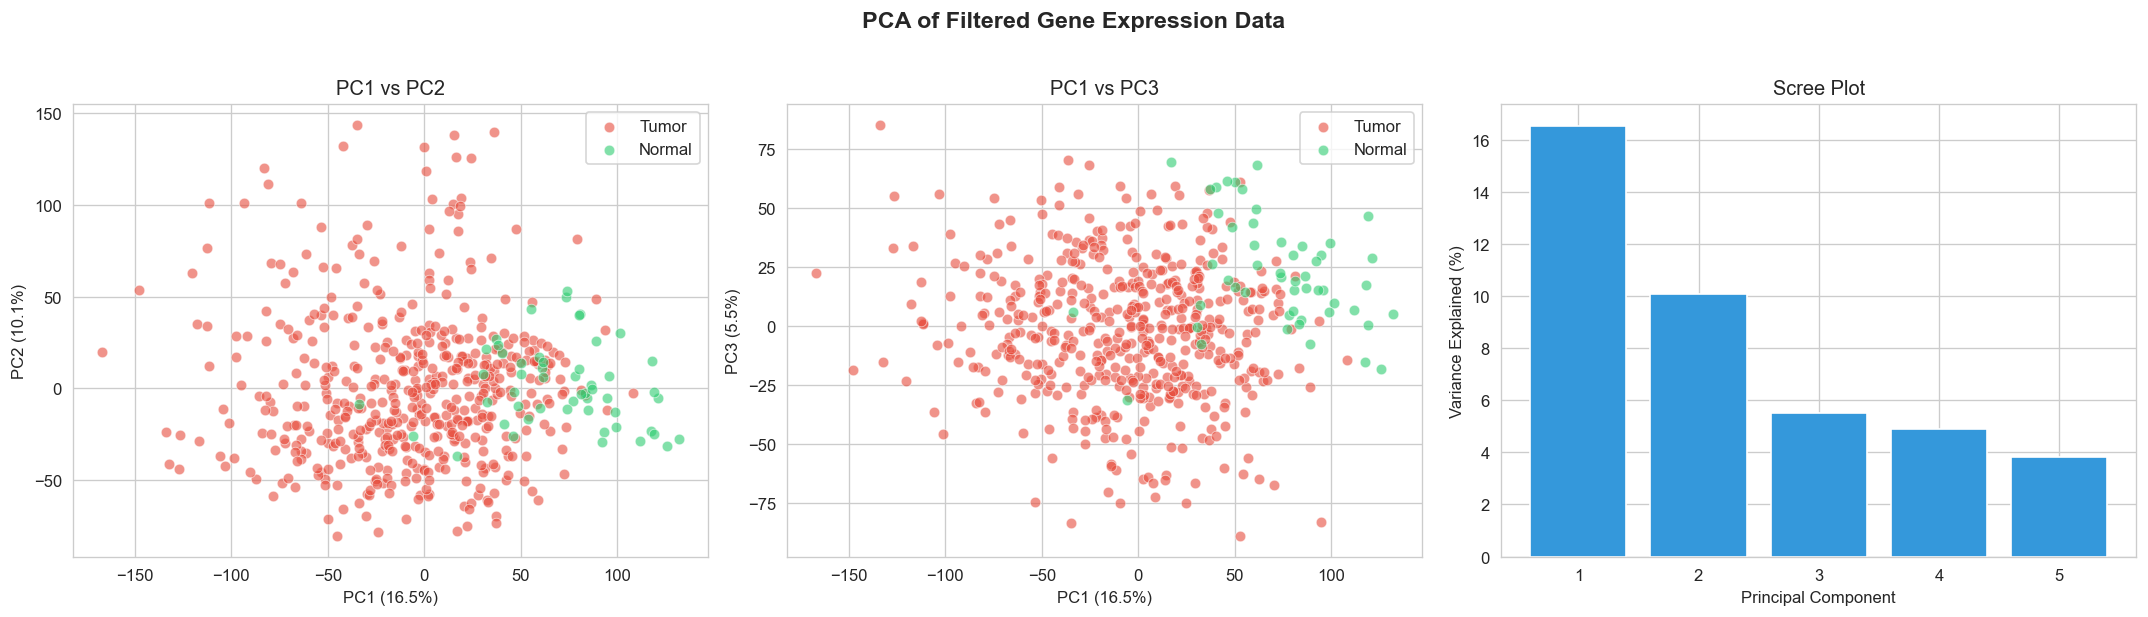

PC1 + PC2 explain 26.6% of total variance

→ Clear separation visible on PC1. Normal samples cluster to the right.
  This confirms classification should be feasible before we even run ML.


In [10]:
# PCA on the filtered data
expr_filtered = expr.loc[:, mask_both]
labels = df['class'].values

pca = PCA(n_components=5)
X_pca = pca.fit_transform(expr_filtered)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PC1 vs PC2
for label, color in [('tumor', '#e74c3c'), ('normal', '#2ecc71')]:
    mask = labels == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=label.capitalize(),
                   alpha=0.6, s=40, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PC1 vs PC2')
axes[0].legend()

# PC1 vs PC3
for label, color in [('tumor', '#e74c3c'), ('normal', '#2ecc71')]:
    mask = labels == label
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 2], c=color, label=label.capitalize(),
                   alpha=0.6, s=40, edgecolors='white', linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')
axes[1].set_title('PC1 vs PC3')
axes[1].legend()

# Scree plot
axes[2].bar(range(1, 6), pca.explained_variance_ratio_ * 100, color='#3498db', edgecolor='white')
axes[2].set_xlabel('Principal Component')
axes[2].set_ylabel('Variance Explained (%)')
axes[2].set_title('Scree Plot')
axes[2].set_xticks(range(1, 6))

plt.suptitle('PCA of Filtered Gene Expression Data', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

total_var = sum(pca.explained_variance_ratio_[:2]) * 100
print(f"PC1 + PC2 explain {total_var:.1f}% of total variance")
print(f"\n→ Clear separation visible on PC1. Normal samples cluster to the right.")
print("  This confirms classification should be feasible before we even run ML.")

## 7. Top Discriminating Genes — What Do They Look Like?

In [11]:
from sklearn.feature_selection import f_classif

# Run ANOVA F-test
X = expr_filtered.values
y = labels
f_scores, p_values = f_classif(X, y)

ranking = pd.DataFrame({
    'gene': expr_filtered.columns,
    'f_score': f_scores,
    'p_value': p_values
}).sort_values('f_score', ascending=False).reset_index(drop=True)

print("Top 15 discriminating genes:")
print(ranking.head(15).to_string(index=False))

Top 15 discriminating genes:
    gene    f_score      p_value
    SIM2 345.370827 3.807586e-60
  EPHA10 300.852290 4.808784e-54
   HOXC6 294.263268 4.096457e-53
     HPN 275.728126 1.860088e-50
   PYCR1 271.122859 8.691523e-50
   LRFN1 255.254400 1.886829e-47
 PIK3C2G 253.975310 2.924883e-47
    SBK1 251.981026 5.801574e-47
 SLC19A1 251.420379 7.035560e-47
  CGREF1 250.346724 1.018249e-46
MARCKSL1 241.975892 1.850051e-45
    DLX1 239.025565 5.179202e-45
    MCF2 227.467451 3.035607e-43
  TRIM36 226.845763 3.785280e-43
   STX19 214.869391 2.754351e-41


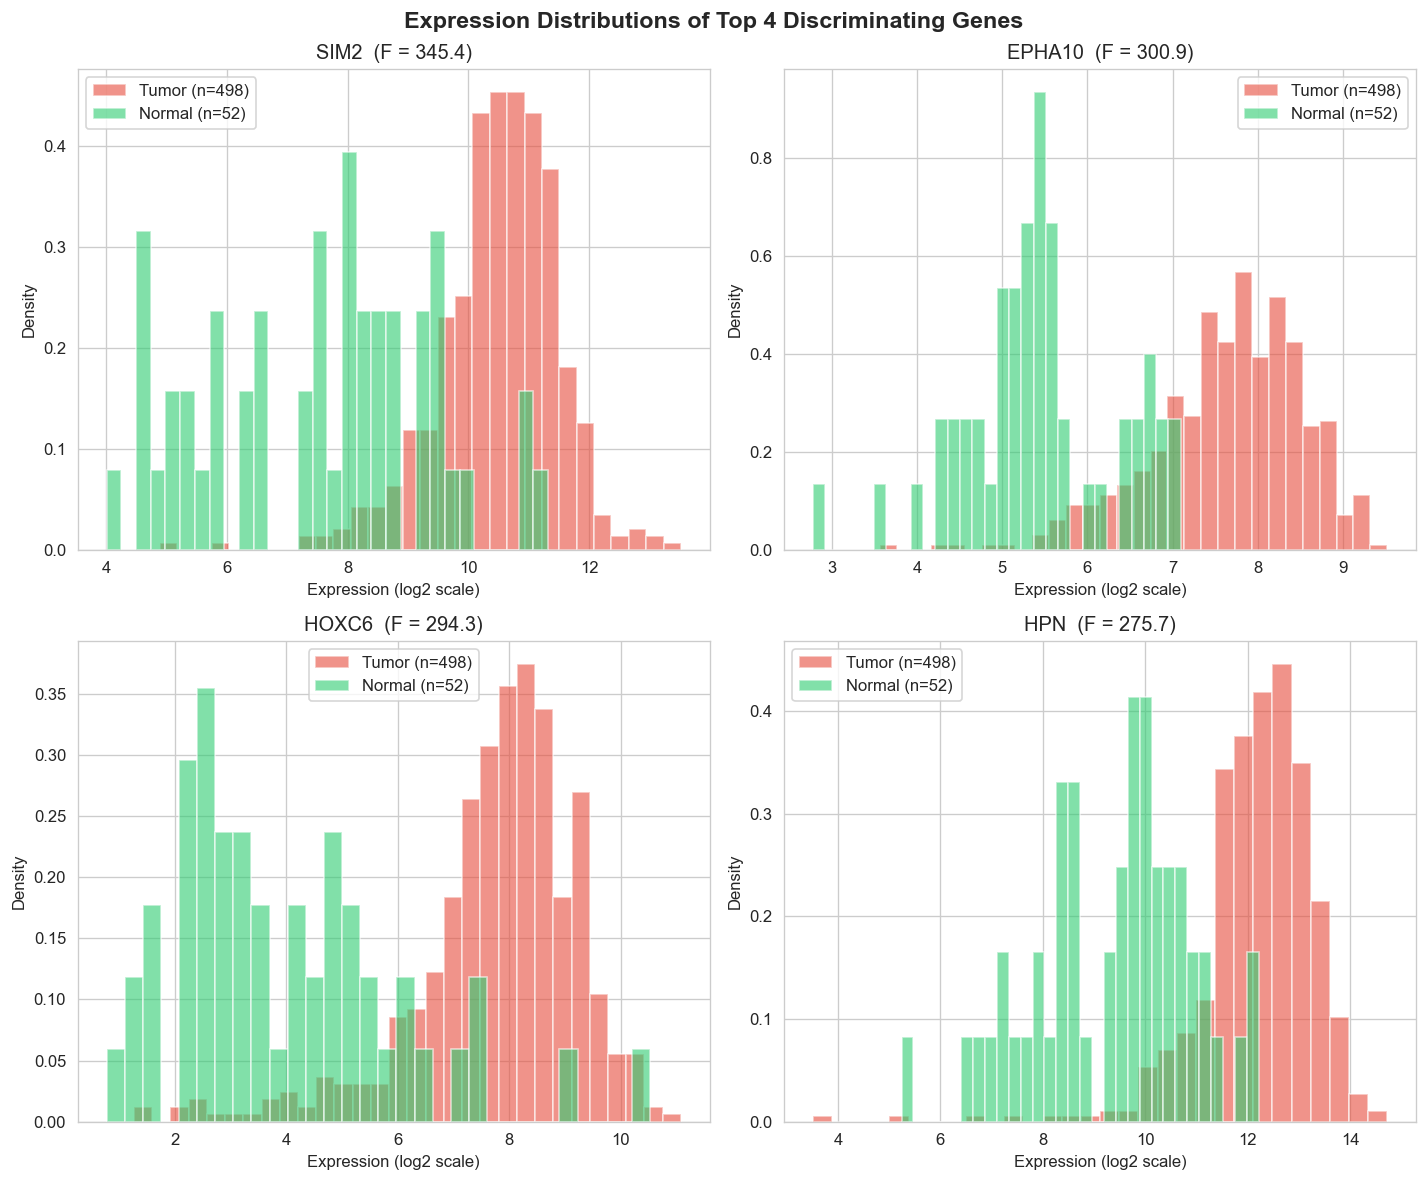

→ Clear separation between tumor (red) and normal (green) for each top gene.
  SIM2 and HOXC6 show higher expression in tumor; PIK3C2G shows lower.
  This visual separation is what the classifiers learn to exploit.


In [12]:
# Expression distributions of top 4 genes: tumor vs normal
top_genes = ranking.head(4)['gene'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, gene in zip(axes.flatten(), top_genes):
    tumor_vals = expr_filtered.loc[labels == 'tumor', gene]
    normal_vals = expr_filtered.loc[labels == 'normal', gene]

    ax.hist(tumor_vals, bins=30, alpha=0.6, color='#e74c3c', label=f'Tumor (n={len(tumor_vals)})', density=True)
    ax.hist(normal_vals, bins=30, alpha=0.6, color='#2ecc71', label=f'Normal (n={len(normal_vals)})', density=True)
    ax.set_xlabel('Expression (log2 scale)')
    ax.set_ylabel('Density')
    ax.set_title(f'{gene}  (F = {ranking[ranking["gene"]==gene]["f_score"].values[0]:.1f})')
    ax.legend()

plt.suptitle('Expression Distributions of Top 4 Discriminating Genes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("→ Clear separation between tumor (red) and normal (green) for each top gene.")
print("  SIM2 and HOXC6 show higher expression in tumor; PIK3C2G shows lower.")
print("  This visual separation is what the classifiers learn to exploit.")

## 8. Correlation Between Top Genes

Are the top discriminating genes independent, or do they correlate with each other?
Highly correlated genes provide redundant information — this is relevant for 
understanding why accuracy plateaus with fewer genes.

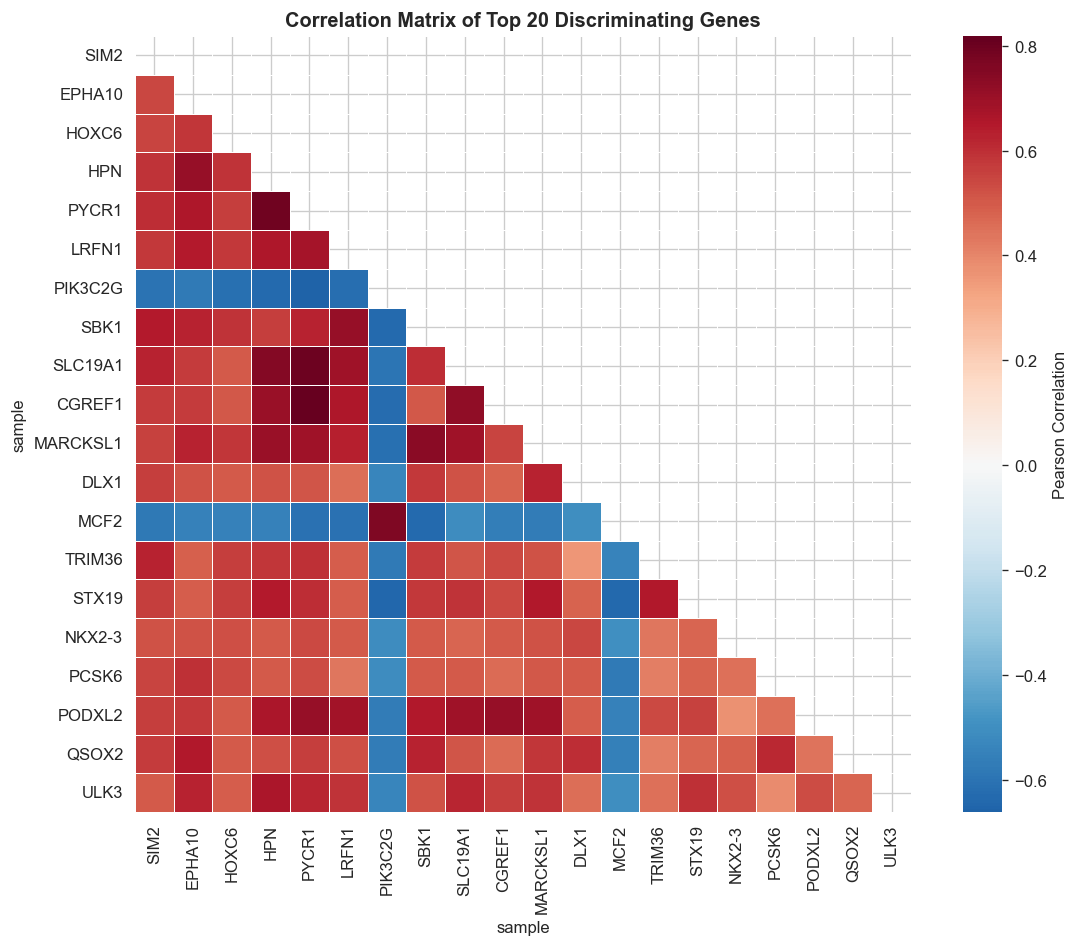

Pairs with |r| > 0.5: 154 out of 190

→ Some genes are correlated (e.g., HOX family genes tend to co-express).
  This redundancy explains why accuracy doesn't keep improving with more genes —
  after ~100-500 genes, additional features are correlated with existing ones.


In [13]:
top20_genes = ranking.head(20)['gene'].tolist()
corr = expr_filtered[top20_genes].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, square=True,
           linewidths=0.5, annot=False, ax=ax,
           cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Correlation Matrix of Top 20 Discriminating Genes', fontweight='bold')
plt.tight_layout()
plt.show()

# Count strong correlations
strong = (corr.abs() > 0.5) & (corr.abs() < 1.0)
n_strong = strong.sum().sum() // 2
print(f"Pairs with |r| > 0.5: {n_strong} out of {len(top20_genes)*(len(top20_genes)-1)//2}")
print(f"\n→ Some genes are correlated (e.g., HOX family genes tend to co-express).")
print("  This redundancy explains why accuracy doesn't keep improving with more genes —")
print("  after ~100-500 genes, additional features are correlated with existing ones.")

## Summary

| Aspect | Finding |
|--------|---------|
| **Samples** | 550 total (498 tumor, 52 normal) — 9.6:1 imbalance |
| **Genes (raw)** | 20,530 |
| **Genes (after filtering)** | 12,802 (37.6% removed) |
| **Low expression removed** | 3,461 genes with mean < 1.0 |
| **Low variance removed** | 4,267 genes in bottom 25th percentile |
| **PCA separation** | Clear tumor/normal clusters on PC1 |
| **Top gene** | SIM2 (F=345.4) — known prostate cancer biomarker |

**Key takeaways for the pipeline:**
1. The class imbalance (9.6:1) means we should evaluate AUC alongside accuracy
2. Filtering removes ~38% of genes but these are noise — the signal is preserved
3. PCA confirms classification is feasible before running any ML
4. Top genes show clear expression differences between classes
5. Gene correlation explains why accuracy plateaus with fewer features